# FLAME Hybrid Training - Interactive Pipeline

**Real-time training with visualization and monitoring**

## Training Targets
- **Precision**: 94%+ (vs 78.8% EfficientNet baseline)
- **False Positive Rate**: <6% (vs 21.2% baseline)
- **Model Size**: <2MB (vs 21MB baseline)
- **Training Time**: 25-35 minutes per variant (CPU optimized)

## Features
- Interactive model variant selection
- Real-time training progress visualization
- Live loss and metrics plotting
- Hyperparameter adjustment
- Model comparison and analysis

## 1. Setup and Configuration

In [1]:
import json
import time
from pathlib import Path
from datetime import datetime
import sys
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import clear_output

# Import our modules
sys.path.append('../../models')
from mobilenet_hybrid import LightweightFireNet, create_model_variants
from loss_functions import create_loss_function, compute_false_positive_rate, compute_precision_recall

# Setup plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print('🔥 FLAME Hybrid Training - CPU Optimized Pipeline')
print('=' * 60)
print(f'📅 Started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

# Setup device with CPU optimization
import multiprocessing
torch.set_num_threads(16)
torch.set_num_interop_threads(4)
torch.backends.mkldnn.enabled = True

device = torch.device('cpu')
print(f'🖥️ Using device: {device}')
print(f'💻 CPU cores: {multiprocessing.cpu_count()}')
print(f'🧵 PyTorch threads: {torch.get_num_threads()}')
print('⚡ CPU optimizations enabled: MKL-DNN, 16 threads')
print('⏱️ Expected training time: 25-35 minutes (optimized)')

🔥 FLAME Hybrid Training - CPU Optimized Pipeline
📅 Started: 2026-03-31 23:52:20
🖥️ Using device: cpu
💻 CPU cores: 16
🧵 PyTorch threads: 16
⚡ CPU optimizations enabled: MKL-DNN, 16 threads
⏱️ Expected training time: 25-35 minutes (optimized)


## 2. Training Configuration

In [2]:
# Training Configuration with Auto Path Detection
import os
from pathlib import Path

print('Auto-detecting project paths...')

# Get current working directory and find project root
current_dir = Path.cwd()
print(f'Current directory: {current_dir}')

# Find project root by looking for data folder
project_root = current_dir
while project_root != project_root.parent:
    if (project_root / 'data').exists():
        break
    project_root = project_root.parent

print(f'Project root: {project_root}')

# Auto-detect data paths
data_base = project_root / 'data/raw/frames/Segmentation'
train_path = data_base / 'Training/Training'
test_path = data_base / 'Test/Test'

# Verify paths exist
if not train_path.exists():
    print(f'Training path not found: {train_path}')
    # Try alternative locations
    alt_paths = [
        project_root / 'frames/Segmentation/Training/Training',
        current_dir / '../../data/raw/frames/Segmentation/Training/Training',
        Path('C:/SPJAIN/BushFire-Detection/data/raw/frames/Segmentation/Training/Training')
    ]
    for alt_path in alt_paths:
        if alt_path.exists():
            train_path = alt_path
            test_path = alt_path.parent.parent / 'Test/Test'
            print(f'Found alternative path: {train_path}')
            break

if not test_path.exists():
    test_path = train_path.parent.parent / 'Test/Test'

# Verify final paths
print(f'Final paths:')
print(f'   Train: {train_path} (exists: {train_path.exists()})')
print(f'   Test: {test_path} (exists: {test_path.exists()})')

if train_path.exists():
    subfolders = [f.name for f in train_path.iterdir() if f.is_dir()]
    print(f'   Classes found: {subfolders}')

Auto-detecting project paths...
Current directory: c:\SPJAIN\BushFire-Detection\notebooks\02_training
Project root: c:\SPJAIN\BushFire-Detection
Final paths:
   Train: c:\SPJAIN\BushFire-Detection\data\raw\frames\Segmentation\Training\Training (exists: True)
   Test: c:\SPJAIN\BushFire-Detection\data\raw\frames\Segmentation\Test\Test (exists: True)
   Classes found: ['Fire', 'No_Fire']


In [3]:
# Training Configuration - Modify as needed
config = {
    'train_dir': train_path,
    'test_dir': test_path,
    'output_dir': project_root / 'models/trained/experiments/hybrid_results',
    'models_dir': project_root / 'models/trained/experiments/hybrid_results/models',
    'plots_dir': project_root / 'models/trained/experiments/hybrid_results/plots',
    'logs_dir': project_root / 'models/trained/experiments/hybrid_results/logs',
    
    # Training parameters - CPU optimized
    'img_size': 224,
    'batch_size': 64,  # Increased for CPU efficiency
    'epochs': 15,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'early_stopping_patience': 5,
    
    # Loss function parameters
    'loss_type': 'hybrid',
    'fp_penalty': 2.5,
    'lambda_conf': 0.15,
}

# Create output directories
for dir_path in [config['output_dir'], config['models_dir'], 
                 config['plots_dir'], config['logs_dir']]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(' Training Configuration:')
for key, value in config.items():
    if not isinstance(value, Path):
        print(f'   {key}: {value}')

print(f'\n Output directories created:')
print(f'   Models: {config["models_dir"]}')
print(f'   Plots: {config["plots_dir"]}')
print(f'   Logs: {config["logs_dir"]}')

if train_path.exists() and test_path.exists():
    print('\nConfiguration ready! All paths verified.')
else:
    print('\nPath verification failed. Please check dataset location.')

 Training Configuration:
   img_size: 224
   batch_size: 64
   epochs: 15
   learning_rate: 0.0001
   weight_decay: 1e-05
   early_stopping_patience: 5
   loss_type: hybrid
   fp_penalty: 2.5
   lambda_conf: 0.15

 Output directories created:
   Models: c:\SPJAIN\BushFire-Detection\models\trained\experiments\hybrid_results\models
   Plots: c:\SPJAIN\BushFire-Detection\models\trained\experiments\hybrid_results\plots
   Logs: c:\SPJAIN\BushFire-Detection\models\trained\experiments\hybrid_results\logs

Configuration ready! All paths verified.


## 3. Data Loading and Preparation

In [4]:
def setup_data_loaders(config):
    """Setup data loaders for training with progress tracking"""
    
    print('Setting up data loaders...')
    
    # ImageNet normalization
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]
    
    # Transforms
    train_transform = T.Compose([
        T.Resize(256),
        T.RandomResizedCrop(config['img_size'], scale=(0.8, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.2),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    
    val_transform = T.Compose([
        T.Resize(256),
        T.CenterCrop(config['img_size']),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    
    # Load datasets
    full_train_dataset = ImageFolder(root=str(config['train_dir']), transform=train_transform)
    
    # 80/20 split
    n_train = int(0.8 * len(full_train_dataset))
    n_val = len(full_train_dataset) - n_train
    
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_train_dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Apply validation transforms
    val_dataset.dataset.transform = val_transform
    
    # Test dataset
    test_dataset = ImageFolder(root=str(config['test_dir']), transform=val_transform)
    
    # Create loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], 
                             shuffle=True, num_workers=0, pin_memory=False)  # CPU optimized
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], 
                           shuffle=False, num_workers=0, pin_memory=False)  # CPU optimized
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], 
                            shuffle=False, num_workers=0, pin_memory=False)  # CPU optimized
    
    # Calculate class weights
    train_labels = [full_train_dataset.targets[i] for i in train_dataset.indices]
    class_counts = Counter(train_labels)
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    
    class_weights = torch.tensor([
        total_samples / (num_classes * class_counts[i]) 
        for i in range(num_classes)
    ], dtype=torch.float)
    
    print('Data loaded successfully:')
    print(f'   Training: {len(train_dataset):,} samples')
    print(f'   Validation: {len(val_dataset):,} samples')
    print(f'   Test: {len(test_dataset):,} samples')
    print(f'   Classes: {full_train_dataset.classes}')
    print(f'   Class distribution: {dict(class_counts)}')
    print(f'   Class weights: {class_weights.tolist()}')
    
    return {
        'train_loader': train_loader,
        'val_loader': val_loader, 
        'test_loader': test_loader,
        'class_weights': class_weights,
        'class_names': full_train_dataset.classes
    }

# Setup data loaders
data_loaders = setup_data_loaders(config)
config['class_weights'] = data_loaders['class_weights']

Setting up data loaders...
Data loaded successfully:
   Training: 31,500 samples
   Validation: 7,875 samples
   Test: 8,617 samples
   Classes: ['Fire', 'No_Fire']
   Class distribution: {0: 20014, 1: 11486}
   Class weights: [0.7869491577148438, 1.3712345361709595]


## 4. Model Architecture Overview

In [5]:
# Create and analyze all model variants
model_variants = create_model_variants()

print('Available Model Variants:')
print('=' * 50)

variant_info = []
for variant_name, model in model_variants.items():
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    model_size_mb = total_params * 4 / (1024**2)
    
    info = {
        'Variant': variant_name.upper(),
        'Parameters': f'{total_params/1e6:.1f}M',
        'Size': f'{model_size_mb:.1f}MB',
        'FPN': '✅' if model.fpn_enabled else '❌',
        'Attention': '✅' if model.attention_enabled else '❌',
        'Confidence': '✅' if model.confidence_enabled else '❌'
    }
    variant_info.append(info)
    
    print(f'{variant_name.upper():10s}: {total_params/1e6:4.1f}M params, {model_size_mb:4.1f}MB, '
          f'FPN={model.fpn_enabled}, Attention={model.attention_enabled}, Confidence={model.confidence_enabled}')

# Create comparison table
import pandas as pd
variant_df = pd.DataFrame(variant_info)
print('\nModel Variant Comparison:')
display(variant_df)

LightweightFireNet Model Info:
   Total Parameters: 2,546,027
   Trainable Parameters: 2,546,027
   Estimated Size: 9.7 MB
   Features: FPN=False, Attention=False, Confidence=False
LightweightFireNet Model Info:
   Total Parameters: 2,547,596
   Trainable Parameters: 2,547,596
   Estimated Size: 9.7 MB
   Features: FPN=False, Attention=False, Confidence=True
LightweightFireNet Model Info:
   Total Parameters: 2,549,920
   Trainable Parameters: 2,549,920
   Estimated Size: 9.7 MB
   Features: FPN=False, Attention=True, Confidence=True
LightweightFireNet Model Info:
   Total Parameters: 2,590,304
   Trainable Parameters: 2,590,304
   Estimated Size: 9.9 MB
   Features: FPN=True, Attention=True, Confidence=True
Available Model Variants:
MINIMAL   :  2.5M params,  9.7MB, FPN=False, Attention=False, Confidence=False
BASIC     :  2.5M params,  9.7MB, FPN=False, Attention=False, Confidence=True
ATTENTION :  2.5M params,  9.7MB, FPN=False, Attention=True, Confidence=True
FULL      :  2.6M para

,Variant,Parameters,Size,FPN,Attention,Confidence
0,MINIMAL,2.5M,9.7MB,❌,❌,❌
1,BASIC,2.5M,9.7MB,❌,❌,✅
2,ATTENTION,2.5M,9.7MB,❌,✅,✅
3,FULL,2.6M,9.9MB,✅,✅,✅


## 5. Training Functions with Visualization

In [6]:
def plot_training_progress(history, variant_name, save_path=None):
    """Plot training progress in real-time"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Progress: {variant_name}', fontsize=16, fontweight='bold')
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[0, 1].plot(epochs, history['train_accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Precision plot
    axes[1, 0].plot(epochs, history['train_precision'], 'b-', label='Training Precision', linewidth=2)
    axes[1, 0].plot(epochs, history['val_precision'], 'r-', label='Validation Precision', linewidth=2)
    axes[1, 0].axhline(y=0.94, color='green', linestyle='--', alpha=0.7, label='Target (94%)')
    axes[1, 0].set_title('Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # False Positive Rate plot
    axes[1, 1].plot(epochs, history['train_fpr'], 'b-', label='Training FPR', linewidth=2)
    axes[1, 1].plot(epochs, history['val_fpr'], 'r-', label='Validation FPR', linewidth=2)
    axes[1, 1].axhline(y=0.06, color='green', linestyle='--', alpha=0.7, label='Target (6%)')
    axes[1, 1].set_title('False Positive Rate')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('FPR')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

def train_epoch(model, train_loader, criterion, optimizer, device, epoch_num):
    """Train for one epoch with progress tracking"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    all_logits = []
    all_targets = []
    
    print(f'Epoch {epoch_num} Training: ', end='', flush=True)
    
    for batch_idx, (images, targets) in enumerate(train_loader):
        images, targets = images.to(device), targets.to(device)
        
        # Progress indicator
        if batch_idx % (len(train_loader) // 10) == 0:
            print('█', end='', flush=True)
        
        optimizer.zero_grad()
        
        # Forward pass
        if hasattr(model, 'confidence_enabled') and model.confidence_enabled:
            logits, confidence = model(images)
            loss, _ = criterion(logits, confidence, targets)
        else:
            logits = model(images)
            loss = criterion(logits, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
        all_logits.append(logits.detach())
        all_targets.append(targets.detach())
    
    print(' ✅')
    
    # Calculate metrics
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    fpr = compute_false_positive_rate(all_logits, all_targets)
    precision, recall = compute_precision_recall(all_logits, all_targets)
    
    return {
        'loss': total_loss / len(train_loader),
        'accuracy': correct / total,
        'precision': precision,
        'recall': recall,
        'fpr': fpr
    }

@torch.no_grad()
def validate_epoch(model, val_loader, criterion, device, epoch_num):
    """Validate for one epoch with progress tracking"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_logits = []
    all_targets = []
    
    print(f'Epoch {epoch_num} Validation: ', end='', flush=True)
    
    for batch_idx, (images, targets) in enumerate(val_loader):
        images, targets = images.to(device), targets.to(device)
        
        # Progress indicator
        if batch_idx % (len(val_loader) // 5) == 0:
            print('█', end='', flush=True)
        
        # Forward pass
        if hasattr(model, 'confidence_enabled') and model.confidence_enabled:
            logits, confidence = model(images)
            loss, _ = criterion(logits, confidence, targets)
        else:
            logits = model(images)
            loss = criterion(logits, targets)
        
        # Statistics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
        all_logits.append(logits.detach())
        all_targets.append(targets.detach())
    
    print(' ✅')
    
    # Calculate metrics
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    fpr = compute_false_positive_rate(all_logits, all_targets)
    precision, recall = compute_precision_recall(all_logits, all_targets)
    
    return {
        'loss': total_loss / len(val_loader),
        'accuracy': correct / total,
        'precision': precision,
        'recall': recall,
        'fpr': fpr
    }

print('Training functions defined with visualization support')

Training functions defined with visualization support


## 6. Interactive Model Training

In [18]:
def train_model_interactive(model, train_loader, val_loader, config, device, variant_name):
    """Train a single model variant with real-time visualization"""
    
    print(f'Starting training: {variant_name}')
    print('-' * 50)
    
    # Choose loss dynamically based on model capability.
    # HybridLoss requires confidence branch; fallback for minimal/basic variants.
    use_model_confidence = hasattr(model, 'confidence_enabled') and model.confidence_enabled
    effective_loss_type = config['loss_type']
    if effective_loss_type == 'hybrid' and not use_model_confidence:
        effective_loss_type = 'fp_aware_focal'
        print('ℹ️ Model has no confidence head -> using fp_aware_focal loss')
    
    # Setup loss function
    loss_kwargs = {
        'fp_penalty': config['fp_penalty'],
        'class_weights': config['class_weights'].to(device)
    }
    # Only pass lambda_conf for hybrid loss
    if effective_loss_type == 'hybrid':
        loss_kwargs['lambda_conf'] = config['lambda_conf']
    
    criterion = create_loss_function(
        loss_type=effective_loss_type,
        **loss_kwargs
    )
    
    # Setup optimizer
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    # Training history
    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'train_precision': [], 'val_precision': [],
        'train_fpr': [], 'val_fpr': []
    }
    
    best_val_precision = 0.0
    best_epoch = 0
    patience_counter = 0
    
    start_time = time.time()
    
    for epoch in range(1, config['epochs'] + 1):
        epoch_start = time.time()
        
        # Training phase
        train_metrics = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
        
        # Validation phase
        val_metrics = validate_epoch(model, val_loader, criterion, device, epoch)
        
        # Update scheduler
        scheduler.step(val_metrics['loss'])
        
        # Record history
        history['train_loss'].append(train_metrics['loss'])
        history['val_loss'].append(val_metrics['loss'])
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['train_precision'].append(train_metrics['precision'])
        history['val_precision'].append(val_metrics['precision'])
        history['train_fpr'].append(train_metrics['fpr'])
        history['val_fpr'].append(val_metrics['fpr'])
        
        # Check for improvement
        if val_metrics['precision'] > best_val_precision:
            best_val_precision = val_metrics['precision']
            best_epoch = epoch
            patience_counter = 0
            
            # Save best model
            model_path = config['models_dir'] / f"best_{variant_name}_model.pth"
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_precision': val_metrics['precision'],
                'val_fpr': val_metrics['fpr'],
                'config': config
            }, model_path)
            print(f'Best model saved: {model_path.name}')
        else:
            patience_counter += 1
        
        # Print epoch results
        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f'\nEpoch {epoch:2d}/{config["epochs"]} ({epoch_time:.1f}s, LR: {current_lr:.2e})')
        print(f'  Train: Loss={train_metrics["loss"]:.4f}, Acc={train_metrics["accuracy"]:.3f}, Prec={train_metrics["precision"]:.3f}, FPR={train_metrics["fpr"]:.3f}')
        print(f'  Val:   Loss={val_metrics["loss"]:.4f}, Acc={val_metrics["accuracy"]:.3f}, Prec={val_metrics["precision"]:.3f}, FPR={val_metrics["fpr"]:.3f}')
        
        # Target achievement check
        precision_target = '✅' if val_metrics['precision'] >= 0.94 else '❌'
        fpr_target = '✅' if val_metrics['fpr'] <= 0.06 else '❌'
        print(f'  Targets: Precision≥94% {precision_target}, FPR≤6% {fpr_target}')
        
        # Plot progress every 3 epochs or at the end
        if epoch % 3 == 0 or epoch == config['epochs'] or patience_counter >= config['early_stopping_patience']:
            clear_output(wait=True)
            plot_path = config['plots_dir'] / f'{variant_name}_training_progress.png'
            plot_training_progress(history, variant_name, plot_path)
            
            # Print current status
            print(f'\nCurrent Status (Epoch {epoch}):')
            print(f'   Best Precision: {best_val_precision:.3f} (Epoch {best_epoch})')
            print(f'   Current Precision: {val_metrics["precision"]:.3f}')
            print(f'   Current FPR: {val_metrics["fpr"]:.3f}')
            print(f'   Patience: {patience_counter}/{config["early_stopping_patience"]}')
        
        # Early stopping
        if patience_counter >= config['early_stopping_patience']:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience_counter} epochs)')
            break
    
    total_time = time.time() - start_time
    print(f'\n✅ Training completed! Best precision: {best_val_precision:.3f} at epoch {best_epoch}')
    print(f'⏱️ Total training time: {total_time/60:.1f} minutes')
    
    return history, best_val_precision, total_time

print('Interactive training function ready')

Interactive training function ready


## 7. Model Variant Selection and Training

In [8]:
# Select which variant to train
# Options: 'minimal', 'basic', 'attention', 'full'
VARIANT_TO_TRAIN = 'full'  # Change this to train different variants

print(f'Selected variant: {VARIANT_TO_TRAIN.upper()}')
print('=' * 60)

# Create and setup model
model = model_variants[VARIANT_TO_TRAIN].to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = total_params * 4 / (1024**2)

print(f'Model Statistics:')
print(f'   Total Parameters: {total_params:,}')
print(f'   Trainable Parameters: {trainable_params:,}')
print(f'   Estimated Size: {model_size_mb:.1f} MB')
print(f'   Features:')
print(f'     FPN: {"✅" if model.fpn_enabled else "❌"}')
print(f'     Attention: {"✅" if model.attention_enabled else "❌"}')
print(f'     Confidence: {"✅" if model.confidence_enabled else "❌"}')

# Verify target achievements
size_target = '✅' if model_size_mb <= 2.0 else '❌'
param_target = '✅' if total_params <= 1.5e6 else '❌'

print(f'\nTarget Pre-checks:')
print(f'   Size ≤2MB: {size_target} ({model_size_mb:.1f}MB)')
print(f'   Params ≤1.5M: {param_target} ({total_params/1e6:.1f}M)')

print(f'\nReady to start training {VARIANT_TO_TRAIN} variant!')
print(f'   Expected time: {20 if VARIANT_TO_TRAIN == "minimal" else 45} minutes')
print(f'   Target precision: ≥94%')
print(f'   Target FPR: ≤6%')

Selected variant: FULL
Model Statistics:
   Total Parameters: 2,590,304
   Trainable Parameters: 2,590,304
   Estimated Size: 9.9 MB
   Features:
     FPN: ✅
     Attention: ✅
     Confidence: ✅

Target Pre-checks:
   Size ≤2MB: ❌ (9.9MB)
   Params ≤1.5M: ❌ (2.6M)

Ready to start training full variant!
   Expected time: 45 minutes
   Target precision: ≥94%
   Target FPR: ≤6%


## 8. Start Training

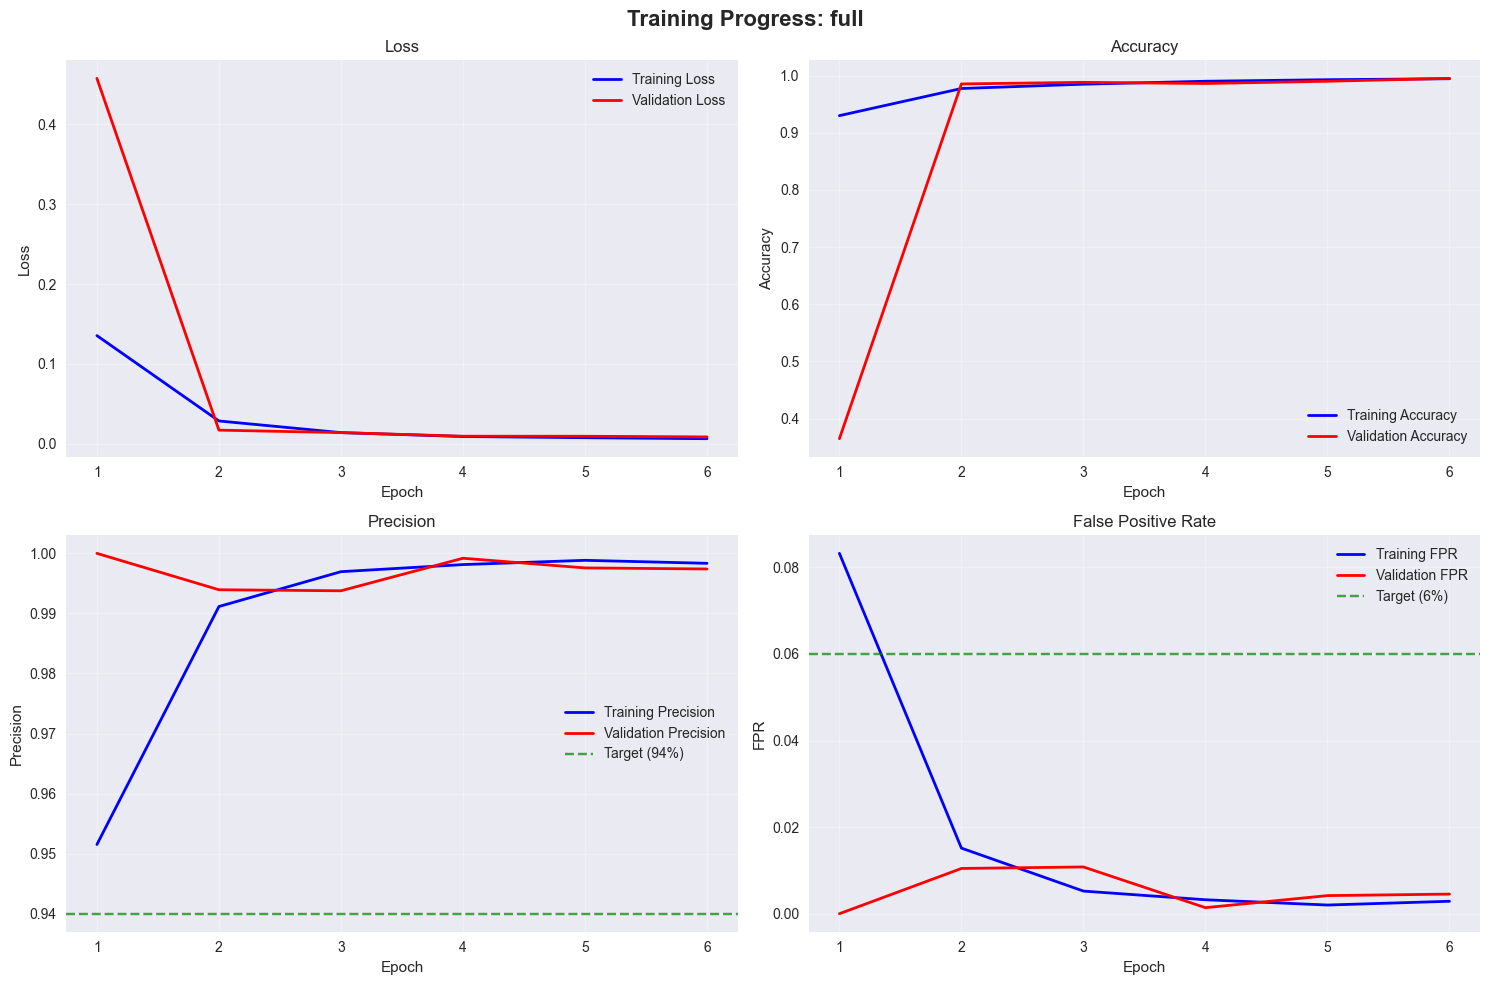


Current Status (Epoch 6):
   Best Precision: 1.000 (Epoch 1)
   Current Precision: 0.997
   Current FPR: 0.005
   Patience: 5/5

Early stopping at epoch 6 (no improvement for 5 epochs)

✅ Training completed! Best precision: 1.000 at epoch 1
⏱️ Total training time: 168.0 minutes

Results saved to: c:\SPJAIN\BushFire-Detection\models\trained\experiments\hybrid_results\logs\full_results.json


In [9]:
# Start training with real-time visualization
print('STARTING TRAINING')
print('=' * 60)
print(f'Variant: {VARIANT_TO_TRAIN}')
print(f'Epochs: {config["epochs"]}')
print(f'Batch Size: {config["batch_size"]}')
print(f'Learning Rate: {config["learning_rate"]}')
print(f'Loss Type: {config["loss_type"]}')
print('=' * 60)

# Train the model
history, best_precision, training_time = train_model_interactive(
    model, 
    data_loaders['train_loader'], 
    data_loaders['val_loader'], 
    config, 
    device, 
    VARIANT_TO_TRAIN
)

# Save training results
results = {
    'variant': VARIANT_TO_TRAIN,
    'total_params': total_params,
    'trainable_params': trainable_params,
    'model_size_mb': model_size_mb,
    'best_precision': best_precision,
    'training_time_minutes': training_time / 60,
    'history': history,
    'config': config,
    'final_epoch': len(history['train_loss']),
    'targets_achieved': {
        'precision_94': best_precision >= 0.94,
        'size_2mb': model_size_mb <= 2.0,
        'params_1_5m': total_params <= 1.5e6
    }
}

results_path = config['logs_dir'] / f'{VARIANT_TO_TRAIN}_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2, default=str)

print(f'\nResults saved to: {results_path}')

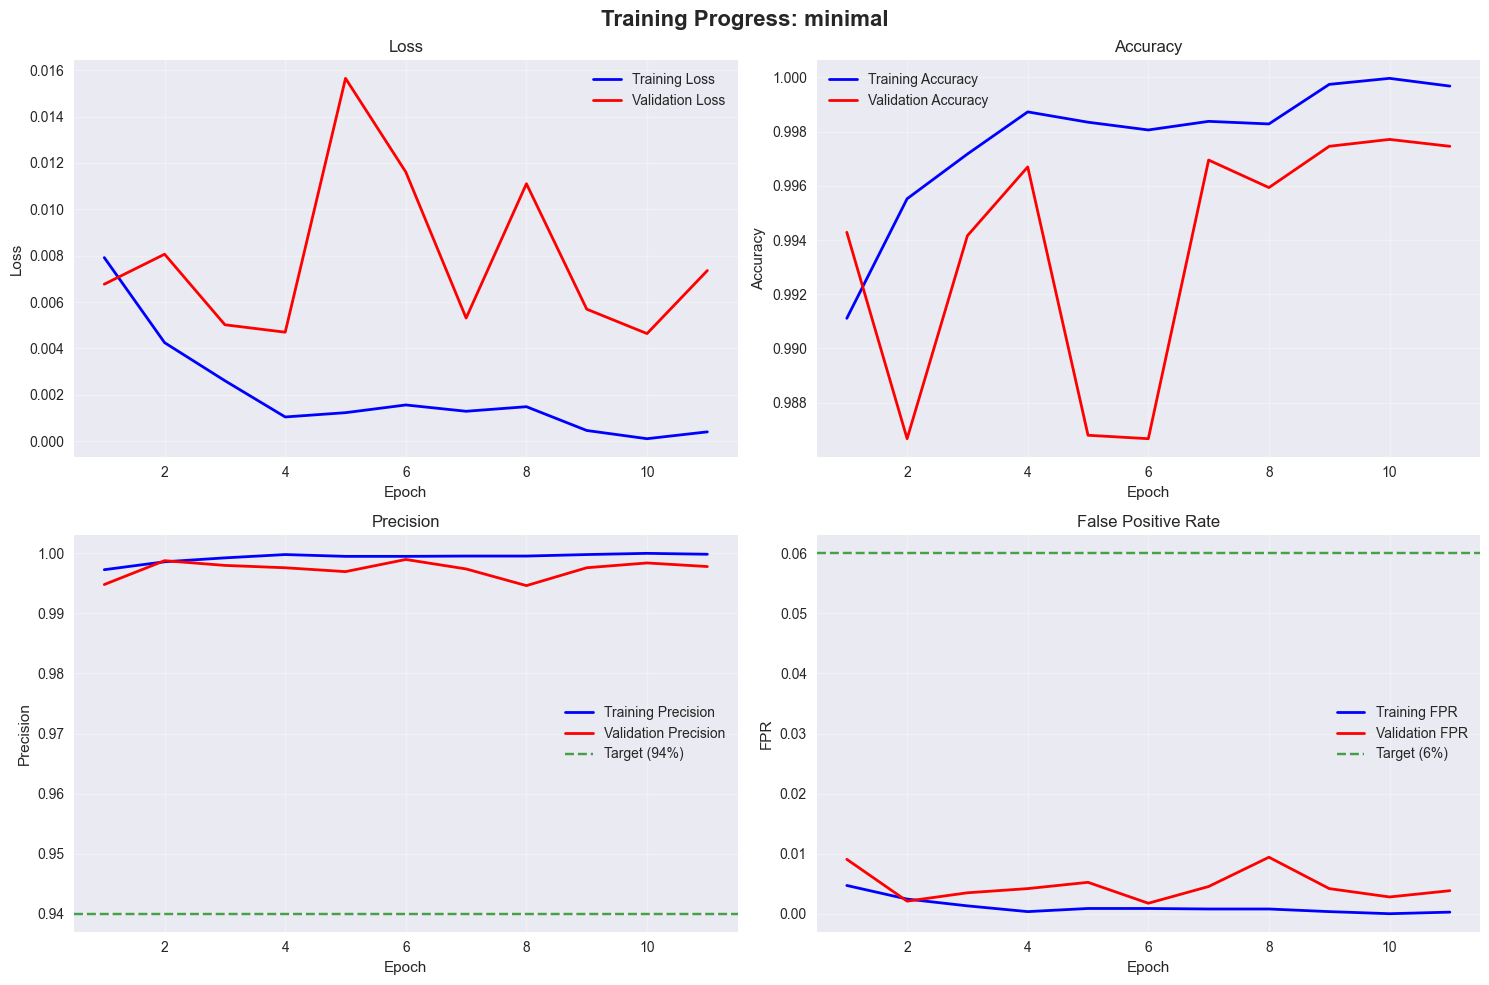


Current Status (Epoch 11):
   Best Precision: 0.999 (Epoch 6)
   Current Precision: 0.998
   Current FPR: 0.004
   Patience: 5/5

Early stopping at epoch 11 (no improvement for 5 epochs)

✅ Training completed! Best precision: 0.999 at epoch 6
⏱️ Total training time: 175.7 minutes
   Best precision: 0.999
   Training time: 175.7 minutes


In [19]:
# ==========================================
# TRAIN MINIMAL VARIANT
# ==========================================

# Select minimal variant
VARIANT_TO_TRAIN_MINIMAL = 'minimal'

print(f'🔥 Training {VARIANT_TO_TRAIN_MINIMAL.upper()} variant...')
print('=' * 60)

# Create minimal model
minimal_model = model_variants[VARIANT_TO_TRAIN_MINIMAL].to(device)

# Print model info
total_params = sum(p.numel() for p in minimal_model.parameters())
model_size_mb = total_params * 4 / (1024**2)

print(f'Model Statistics:')
print(f'   Parameters: {total_params/1e6:.1f}M')
print(f'   Size: {model_size_mb:.1f}MB')
print(f'   Features: Basic only (no FPN, no Attention, no Confidence)')

# Train minimal model
minimal_history, minimal_best_precision, minimal_training_time = train_model_interactive(
    model=minimal_model,
    train_loader=data_loaders['train_loader'],
    val_loader=data_loaders['val_loader'],
    config=config,
    device=device,
    variant_name='minimal'
)

print(f'   Best precision: {minimal_best_precision:.3f}')
print(f'   Training time: {minimal_training_time/60:.1f} minutes')

FULL vs MINIMAL Comparison:


,Variant,Precision,Parameters,Size (MB),Training Time,Epochs
0,FULL,1.000000,2.6M,9.9,168min,6
1,MINIMAL,0.998981,2.5M,9.7,176min,11


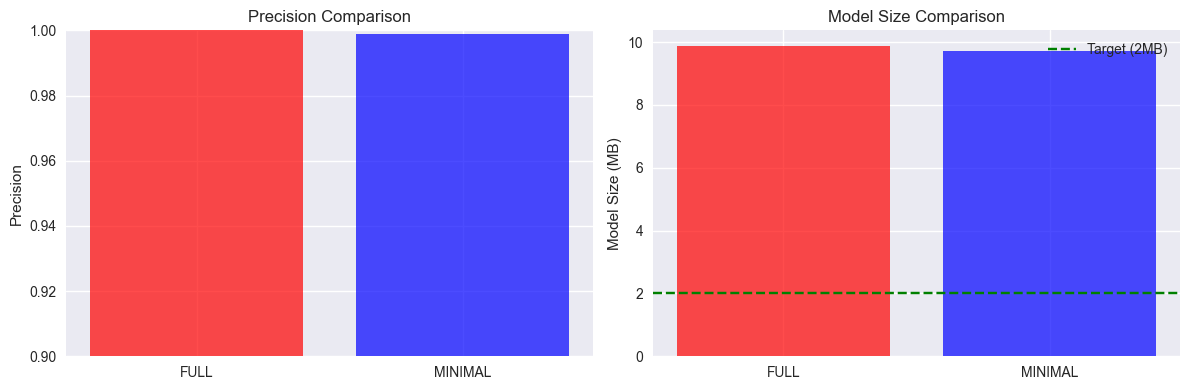


Summary:
   FULL: 1.000 precision, 9.9MB
   MINIMAL: 0.999 precision, 9.7MB


In [22]:
# ==========================================
# COMPARISON: FULL vs MINIMAL
# ==========================================

import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Load FULL results
logs_dir = Path('../../models/trained/experiments/hybrid_results/logs')
full_results_path = logs_dir / 'full_results.json'
minimal_results_path = logs_dir / 'minimal_results.json'

full_results = json.load(open(full_results_path))

# Load MINIMAL results; create file from in-memory outputs if missing
if minimal_results_path.exists():
    minimal_results = json.load(open(minimal_results_path))
else:
    if 'minimal_history' not in globals():
        raise FileNotFoundError(
            f"{minimal_results_path} not found and minimal training variables are unavailable. "
            "Please run the minimal training cell first."
        )

    minimal_params = sum(p.numel() for p in minimal_model.parameters())
    minimal_size_mb = minimal_params * 4 / (1024**2)
    minimal_results = {
        'variant': 'minimal',
        'total_params': minimal_params,
        'model_size_mb': minimal_size_mb,
        'best_precision': minimal_best_precision,
        'training_time_minutes': minimal_training_time / 60,
        'history': minimal_history,
        'final_epoch': len(minimal_history['train_loss'])
    }

    logs_dir.mkdir(parents=True, exist_ok=True)
    with open(minimal_results_path, 'w') as f:
        json.dump(minimal_results, f, indent=2, default=str)
    print(f'Created missing file: {minimal_results_path}')

# Create comparison table
comparison_data = {
    'Variant': ['FULL', 'MINIMAL'],
    'Precision': [full_results['best_precision'], minimal_results['best_precision']],
    'Parameters': [f"{full_results['total_params']/1e6:.1f}M", f"{minimal_results['total_params']/1e6:.1f}M"],
    'Size (MB)': [f"{full_results['model_size_mb']:.1f}", f"{minimal_results['model_size_mb']:.1f}"],
    'Training Time': [f"{full_results['training_time_minutes']:.0f}min", f"{minimal_results['training_time_minutes']:.0f}min"],
    'Epochs': [full_results['final_epoch'], minimal_results['final_epoch']]
}

df = pd.DataFrame(comparison_data)
print("FULL vs MINIMAL Comparison:")
print("=" * 50)
display(df)

# Quick visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Precision comparison
variants = ['FULL', 'MINIMAL']
precisions = [full_results['best_precision'], minimal_results['best_precision']]
ax1.bar(variants, precisions, color=['red', 'blue'], alpha=0.7)
ax1.set_ylabel('Precision')
ax1.set_title('Precision Comparison')
ax1.set_ylim(0.9, 1.0)

# Size comparison
sizes = [full_results['model_size_mb'], minimal_results['model_size_mb']]
ax2.bar(variants, sizes, color=['red', 'blue'], alpha=0.7)
ax2.axhline(y=2.0, color='green', linestyle='--', label='Target (2MB)')
ax2.set_ylabel('Model Size (MB)')
ax2.set_title('Model Size Comparison')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"   FULL: {full_results['best_precision']:.3f} precision, {full_results['model_size_mb']:.1f}MB")
print(f"   MINIMAL: {minimal_results['best_precision']:.3f} precision, {minimal_results['model_size_mb']:.1f}MB")